In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import seaborn as sns
import os

In [2]:
data = pd.read_csv(r"data/ai_course_data.csv", encoding='utf-8')
data.head(5)

,Student Id,Quiz_1,Midterm_1,Assignment_1,Assignment_2,Assignment_3,Project,Presentation,Final_Exam_Marks,Total,Grade,Categories
0,1,2.34,6.78,4.56,3.24,4.56,5.67,7.89,24.0,59.04,C+,Pass
1,2,8.17,12.43,2.87,1.87,2.89,2.34,2.34,29.0,61.91,B-,Pass
2,3,5.92,3.21,0.45,4.56,0.76,8.90,5.67,30.0,59.47,C+,Pass
3,4,1.45,9.87,3.12,2.34,3.01,1.23,1.23,33.0,55.25,C+,Pass
4,5,9.78,5.34,0.98,0.98,1.98,9.45,9.01,31.0,68.52,B,Distinction


In [3]:
data.shape

(520, 12)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student Id        520 non-null    int64  
 1   Quiz_1            520 non-null    float64
 2   Midterm_1         520 non-null    float64
 3   Assignment_1      520 non-null    float64
 4   Assignment_2      520 non-null    float64
 5   Assignment_3      520 non-null    float64
 6   Project           520 non-null    float64
 7   Presentation      520 non-null    float64
 8   Final_Exam_Marks  520 non-null    float64
 9   Total             520 non-null    float64
 10  Grade             520 non-null    str    
 11  Categories        520 non-null    str    
dtypes: float64(9), int64(1), str(2)
memory usage: 48.9 KB


In [5]:
data['Grade'].value_counts()

Grade
B+    130
B      81
A-     66
A      62
A+     56
B-     48
D+     41
C+     22
C      12
C-      2
Name: count, dtype: int64

In [6]:
data.dtypes

Student Id            int64
Quiz_1              float64
Midterm_1           float64
Assignment_1        float64
Assignment_2        float64
Assignment_3        float64
Project             float64
Presentation        float64
Final_Exam_Marks    float64
Total               float64
Grade                   str
Categories              str
dtype: object

In [7]:
data.describe()

,Student Id,Quiz_1,Midterm_1,Assignment_1,Assignment_2,Assignment_3,Project,Presentation,Final_Exam_Marks,Total
count,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000
mean,260.500000,6.503635,8.532519,3.428885,3.616098,3.498385,6.879673,7.182154,31.431731,71.073079
std,150.255338,2.152460,3.820372,0.911925,0.911483,0.909357,1.894361,1.818888,8.289712,12.643165
min,1.000000,0.210000,0.120000,0.090000,0.210000,0.120000,0.210000,0.210000,4.000000,40.250000
25%,130.750000,5.120000,5.430000,2.890000,3.210000,2.980000,5.560000,6.010000,30.000000,65.317500
50%,260.500000,6.670000,8.010000,3.560000,3.890000,3.670000,6.950000,7.340000,34.000000,72.150000
75%,390.250000,8.430000,12.362500,4.120000,4.230000,4.120000,8.450000,8.677500,36.000000,79.085000
max,520.000000,9.980000,15.000000,4.980000,4.980000,4.980000,9.980000,9.980000,39.500000,95.030000


In [8]:
data['Categories'].value_counts()

Categories
Distinction    277
Excellent       62
Exceptional     56
Pass            48
Fail            41
Pass            36
Name: count, dtype: int64

In [9]:
data['Categories'].unique()

<StringArray>
['Pass', 'Pass ', 'Distinction', 'Excellent', 'Fail', 'Exceptional']
Length: 6, dtype: str

In [12]:
data['Grade'].unique()

<StringArray>
['C+', 'B-', 'B', 'C', 'A', 'C-', 'D+', 'B+', 'A-', 'A+']
Length: 10, dtype: str

In [23]:
grade_mapping = {
    'A+': 1,
    'A': 2,
    'A-': 3,
    'B+': 4,
    'B': 5,
    'B-': 6,
    'C+': 7,
    'C': 8,
    'C-': 9,
    'D+': 10
}

categories_mapping = {
    'Fail': 0,
    'Pass': 1,
    'Distinction': 2,
    'Excellent': 3,
    'Exceptional': 4
}


In [24]:
data['Grade_Ordinal'] = data['Grade'].map(grade_mapping)

data['Categories_Cleaned'] = data['Categories'].str.strip()
data['Categories_Ordinal'] = data['Categories_Cleaned'].map(categories_mapping)

In [25]:
data['Categories_Cleaned'].unique()

<StringArray>
['Pass', 'Distinction', 'Excellent', 'Fail', 'Exceptional']
Length: 5, dtype: str

In [27]:
print("First 5 rows with new ordinal columns:")
print(data[['Grade', 'Grade_Ordinal', 'Categories', 'Categories_Cleaned', 'Categories_Ordinal']].head())

First 5 rows with new ordinal columns:
  Grade  Grade_Ordinal   Categories Categories_Cleaned  Categories_Ordinal
0    C+              7         Pass               Pass                   1
1    B-              6        Pass                Pass                   1
2    C+              7         Pass               Pass                   1
3    C+              7         Pass               Pass                   1
4     B              5  Distinction        Distinction                   2


In [28]:
data[data['Categories_Ordinal'].isnull()]['Categories_Cleaned'].unique()

<StringArray>
[]
Length: 0, dtype: str

In [40]:
X = data.drop(columns=['Total', 'Grade', 'Categories', 'Grade_Ordinal', 'Categories_Cleaned', 'Categories_Ordinal', 'Cleaned_Grade'])
X.columns

Index(['Student Id', 'Quiz_1', 'Midterm_1', 'Assignment_1', 'Assignment_2',
       'Assignment_3', 'Project', 'Presentation', 'Final_Exam_Marks'],
      dtype='str')

In [35]:
y = data[['Total', 'Grade_Ordinal', 'Categories_Ordinal']]
y.columns

Index(['Total', 'Grade_Ordinal', 'Categories_Ordinal'], dtype='str')

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
y_pred = model.predict(X_test)

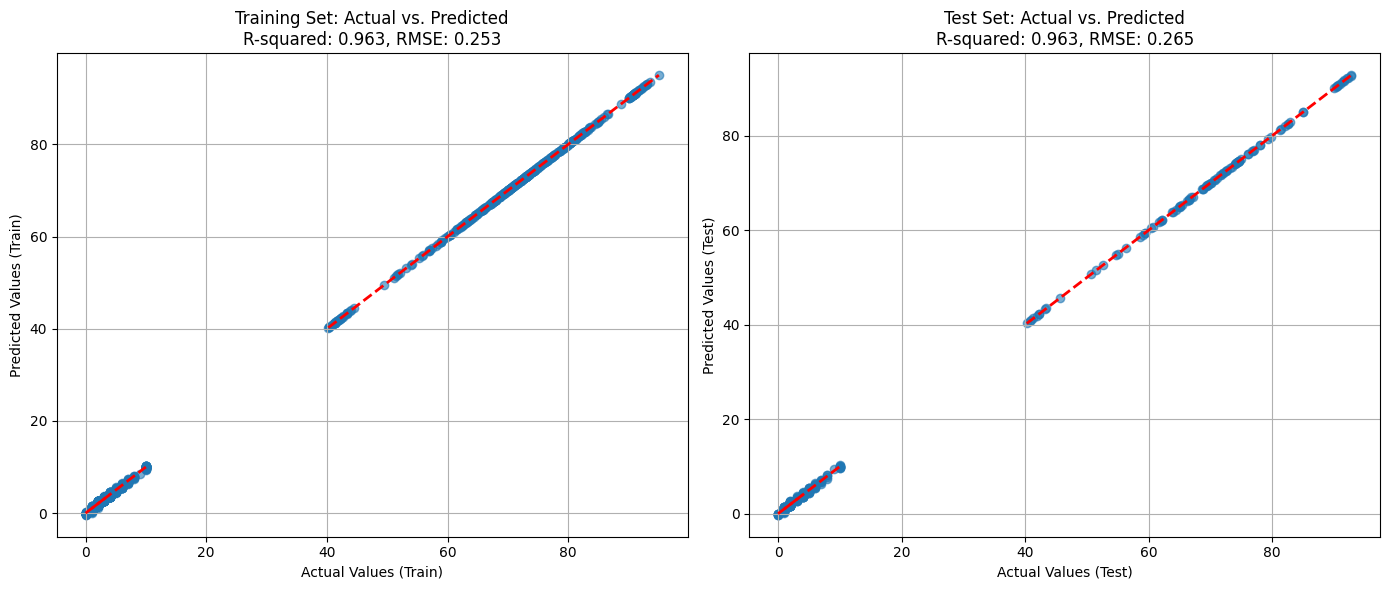

In [39]:
from sklearn.metrics import mean_squared_error, r2_score

# Generate predictions for the training set
y_train_pred = model.predict(X_train)

# Calculate metrics for training set
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

# Calculate metrics for testing set
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test = r2_score(y_test, y_pred)

# Create subplots for visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Training Data
axes[0].scatter(y_train, y_train_pred, alpha=0.6)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2) # Ideal line
axes[0].set_xlabel("Actual Values (Train)")
axes[0].set_ylabel("Predicted Values (Train)")
axes[0].set_title(f"Training Set: Actual vs. Predicted\nR-squared: {r2_train:.3f}, RMSE: {rmse_train:.3f}")
axes[0].grid(True)

# Plot for Test Data
axes[1].scatter(y_test, y_pred, alpha=0.6)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal line
axes[1].set_xlabel("Actual Values (Test)")
axes[1].set_ylabel("Predicted Values (Test)")
axes[1].set_title(f"Test Set: Actual vs. Predicted\nR-squared: {r2_test:.3f}, RMSE: {rmse_test:.3f}")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [42]:
# Function to predict grade and category based on input test scores
def predict_grade_and_category():
    print("Enter the test scores for prediction:")
    quiz_1 = float(input("Quiz_1: "))
    midterm_1 = float(input("Midterm_1: "))
    assignment_1 = float(input("Assignment_1: "))
    assignment_2 = float(input("Assignment_2: "))
    assignment_3 = float(input("Assignment_3: "))
    project = float(input("Project: "))
    presentation = float(input("Presentation: "))
    final_exam_marks = float(input("Final_Exam_Marks: "))

    # Create input DataFrame
    input_data = pd.DataFrame({
        'Student Id': [0],  # Dummy value
        'Quiz_1': [quiz_1],
        'Midterm_1': [midterm_1],
        'Assignment_1': [assignment_1],
        'Assignment_2': [assignment_2],
        'Assignment_3': [assignment_3],
        'Project': [project],
        'Presentation': [presentation],
        'Final_Exam_Marks': [final_exam_marks]
    })

    # Predict
    prediction = model.predict(input_data)

    # Extract predictions
    predicted_total = prediction[0][0]
    predicted_grade_ordinal = round(prediction[0][1])  # Round to nearest integer
    predicted_category_ordinal = round(prediction[0][2])

    # Reverse mappings
    reverse_grade_mapping = {v: k for k, v in grade_mapping.items()}
    reverse_categories_mapping = {v: k for k, v in categories_mapping.items()}

    predicted_grade = reverse_grade_mapping.get(predicted_grade_ordinal, "Unknown")
    predicted_category = reverse_categories_mapping.get(predicted_category_ordinal, "Unknown")

    print(f"\nPredicted Total Score: {predicted_total:.2f}")
    print(f"Predicted Grade: {predicted_grade}")
    print(f"Predicted Category: {predicted_category}")

# Call the function
predict_grade_and_category()

Enter the test scores for prediction:

Predicted Total Score: 78.00
Predicted Grade: A-
Predicted Category: Excellent


**Extract Predictions**

- **Why this is needed**: 

    - Your model is trained to predict three outputs simultaneously (multi-output regression): the total score, the grade as an ordinal number, and the category as an ordinal number. The `model.predict(input_data)` call returns a 2D NumPy array with shape `(1, 3)` (since you're predicting for one input row). `prediction[0]` accesses the first (and only) row of predictions, which is an array like `[predicted_total, predicted_grade_ordinal, predicted_category_ordinal]`.

- **Breaking it down:**

    - `predicted_total = prediction[0][0]`: This grabs the first element, which is the predicted total score (a float, like 85.5).

    - `predicted_grade_ordinal = round(prediction[0][1])`: This grabs the second element (the predicted grade as a number) and rounds it to the nearest integer. For example, if the model predicts 3.7, it rounds to 4. This is because grades are mapped to integers (e.g., 'A+' = 1, 'B+' = 4), so we need whole numbers to match the mapping.

    - `predicted_category_ordinal = round(prediction[0][2])`: Same as above, but for the category (e.g., 'Pass' = 1, 'Excellent' = 3).

- **Why round?** 

    - The model outputs continuous numbers, but your ordinal mappings use integers. Rounding ensures we get valid keys for the reverse lookup (explained below). Without rounding, you'd get floats like 3.2, which wouldn't match any mapping key.

**Reverse Mappings**

- **Why this is needed:**

    - During training, you converted categorical grades and categories to numbers using dictionaries like `grade_mapping = {'A+': 1, 'A': 2, ...}`. The model predicts numbers, but you want to show the user the original strings (e.g., "A-" instead of 3). So, you need to "reverse" the mappings.

- **Breaking it down:**

    - `reverse_grade_mapping = {v: k for k, v in grade_mapping.items()}`: This creates a new dictionary by swapping keys and values. For example, if `grade_mapping` is `{'A+': 1, 'A': 2}`, this becomes `{1: 'A+', 2: 'A'}`. The syntax `{v: k for k, v in grade_mapping.items()}` is a dictionary comprehension that iterates over the original dict's items and flips them.

    - Same for `reverse_categories_mapping`: It flips categories_mapping (e.g., `{'Fail': 0, 'Pass': 1}` becomes `{0: 'Fail', 1: 'Pass'}`).
    
    - `predicted_grade = reverse_grade_mapping.get(predicted_grade_ordinal, "Unknown")`: Uses the rounded ordinal number (e.g., 4) as a key to look up the grade string (e.g., "B+"). The `.get()` method returns the value if the key exists, or "Unknown" if not (in case the rounded number is out of range, like 11).

    - Same for `predicted_category`.

- **Why use `.get()` instead of `[]`?** 

    - It's safer—`[]` would raise a KeyError if the key doesn't exist, while `.get()` returns a default value ("Unknown") without crashing the program.